# Chương 2: Nền Tảng Mạng Nơ-ron (Foundations of Neural Networks)

Mạng nơ-ron nhân tạo là công cụ ML mạnh mẽ, thay đổi cuộc chơi trong NLP từ khoảng 2006 khi **deep learning** ra đời. Chương này trình bày các khái niệm nền tảng: kiến trúc mô hình, huấn luyện, regularization, học không giám sát, và ứng dụng vào language modeling.

---

## 2.1 Mạng Nơ-ron Nhiều Lớp (Multi-layer Neural Networks)

---

### 2.1.1 Perceptron Một Lớp (Single-layer Perceptrons)

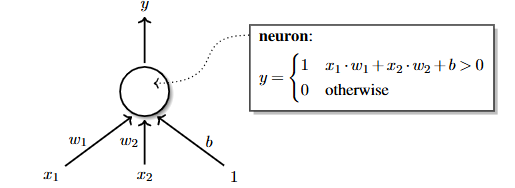

**Perceptron** là mạng nơ-ron đơn giản nhất — lấy cảm hứng từ tế bào thần kinh sinh học: nhận tín hiệu đầu vào, quyết định tín hiệu có được truyền tiếp không.

**Toán học:** Cho vectơ đầu vào $\mathbf{x}$, perceptron thực hiện:

**Bước 1 — Biến đổi affine:**
$$f(\mathbf{x}) = \mathbf{x} \cdot \mathbf{w} + b = \sum_i x_i \cdot w_i + b \tag{2.1}$$

**Bước 2 — Hàm kích hoạt (activation function):**
$$y = \psi(f(\mathbf{x})) = \begin{cases}1 & f(\mathbf{x}) > 0 \\ 0 & \text{otherwise}\end{cases} \tag{2.2}$$

> **Lưu ý:** Perceptron là **bộ phân loại tuyến tính** — ranh giới quyết định là siêu phẳng $\mathbf{x}\cdot\mathbf{w} + b = 0$, dù bản thân hàm kích hoạt bậc thang là phi tuyến.

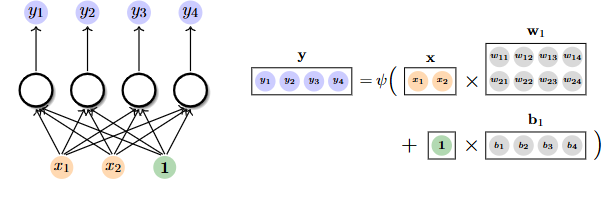

**Nhiều nơ-ron trong một lớp** — gộp thành dạng ma trận với $\mathbf{x} \in \mathbb{R}^m$, $\mathbf{y} \in \mathbb{R}^n$, $W \in \mathbb{R}^{m \times n}$, $\mathbf{b} \in \mathbb{R}^n$:

$$\mathbf{y} = \psi(f(\mathbf{x})), \quad f(\mathbf{x}) = \mathbf{x} \cdot W + \mathbf{b} \tag{2.3, 2.4}$$

Mỗi cột của $W$ là trọng số của một nơ-ron. Đầu ra $\mathbf{y}$ là vectơ đặc trưng mới.

---

### Các Hàm Kích Hoạt Phổ Biến

| Tên | Công thức | Đặc điểm |
|---|---|---|
| **Identity** | $y_i = s_i$ | Không biến đổi |
| **Binary Step** | $y_i = \mathbf{1}[s_i > 0]$ | Không khả vi tại 0 |
| **Sigmoid** | $y_i = \frac{1}{1+e^{-s_i}}$ | Đầu ra $(0,1)$, dễ tối ưu, saturate ở hai đầu |
| **Tanh** | $y_i = \frac{e^{s_i}-e^{-s_i}}{e^{s_i}+e^{-s_i}}$ | Đầu ra $(-1,1)$, zero-centered |
| **Hard Tanh** | $y_i = \text{clip}(s_i, -1, 1)$ | Xấp xỉ tuyến tính của Tanh |
| **ReLU** | $y_i = \max(0, s_i)$ | Đơn giản, tránh vanishing gradient, phổ biến nhất |
| **Softplus** | $y_i = \ln(1 + e^{s_i})$ | Làm mịn của ReLU |
| **Softmax** | $y_i = \frac{e^{s_i}}{\sum_{i'} e^{s_{i'}}}$ | Đầu ra là phân phối xác suất (tổng = 1) |
| **Maxout** | $y_i = \max(s_1,\ldots,s_n)$ | Tổng quát hóa ReLU |
| **Gaussian** | $y_i = \exp\!\left(-\frac{(s_i-\mu_i)^2}{2\sigma_i^2}\right)$ | Dạng chuông |

> **Chọn activation function:**
> - **Phân loại đa lớp** → Softmax ở lớp output
> - **Lớp ẩn** → ReLU là mặc định phổ biến nhất
> - **Đầu ra nhị phân** → Sigmoid
> - **Cần output âm** → Tanh

---

### 2.1.2 Xếp Chồng Nhiều Lớp (Stacking Multiple Layers)

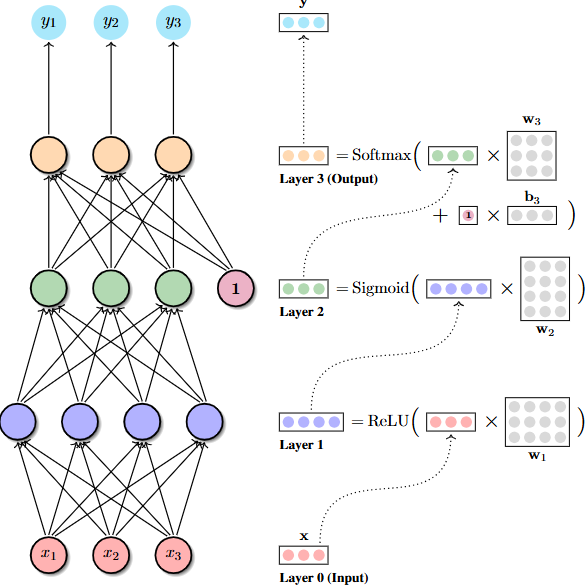

**Mạng nơ-ron nhiều lớp** = xếp chồng nhiều lớp, đầu ra lớp này là đầu vào lớp tiếp theo → **hợp của các hàm**:

$$\mathbf{y} = \text{Softmax}\!\left(\text{Sigmoid}\!\left(\text{ReLU}(\mathbf{x} \cdot W_1) \cdot W_2\right) \cdot W_3 + \mathbf{b}_3\right) \tag{2.5}$$

với $W_1 \in \mathbb{R}^{3\times4}$, $W_2 \in \mathbb{R}^{4\times3}$, $W_3 \in \mathbb{R}^{3\times3}$, $\mathbf{b}_3 \in \mathbb{R}^3$.

**Kết nối đầy đủ (fully connected):** Mọi nơ-ron lớp $k$ kết nối với mọi nơ-ron lớp $k+1$.

Quá trình forward:

```
Input x
  → Layer 1: h₁ = ReLU(x · W₁)
  → Layer 2: h₂ = Sigmoid(h₁ · W₂)
  → Layer 3: y  = Softmax(h₂ · W₃ + b₃)
```

**Hai khái niệm về kích thước mạng:**

- **Độ sâu (depth):** Số lớp (kể cả input layer). Ví dụ trên có depth = 4.
- **Độ rộng (width):** Số nơ-ron trong một lớp. Ví dụ trên có output width = 3.

> **Định lý xấp xỉ phổ quát (Universal Approximation Theorem):** Mạng 2 lớp với Sigmoid có thể xấp xỉ **bất kỳ hàm liên tục nào** (Cybenko, 1989). Tuy nhiên trong thực tế, **tăng độ sâu** thường hiệu quả hơn tăng độ rộng cho các bài toán phức tạp.

Loại mạng này gọi là **Feed-forward Neural Network (FFNN)** — không có chu trình, dữ liệu chỉ đi một chiều (sẽ có ngoại lệ ở Mục 2.3).

---

### 2.1.3 Đồ Thị Tính Toán (Computation Graphs)

**Đồ thị tính toán** là cách biểu diễn mạng nơ-ron dưới dạng đồ thị có hướng:
- **Nút (node):** phép toán hoặc biến số
- **Cạnh (edge):** luồng dữ liệu từ nút này sang nút khác

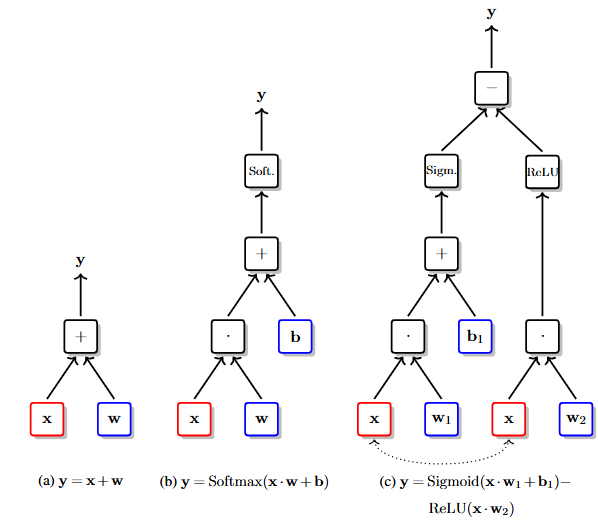

Ví dụ ba hàm và đồ thị tính toán tương ứng:

$$y = x + w \tag{2.6}$$
$$y = \text{Softmax}(\mathbf{x} \cdot W + \mathbf{b}) \tag{2.7}$$
$$y = \text{Sigmoid}(\mathbf{x} \cdot W_1 + \mathbf{b}_1) - \text{ReLU}(\mathbf{x} \cdot W_2) \tag{2.8}$$

Hàm (2.8) phân rã thành:

$$y = h_1 - h_2 \tag{2.9}$$
$$h_1 = \text{Sigmoid}(\mathbf{x} \cdot W_1 + \mathbf{b}_1) \tag{2.10}$$
$$h_2 = \text{ReLU}(\mathbf{x} \cdot W_2) \tag{2.11}$$

**Hai ứng dụng chính của đồ thị tính toán:**

**1. Forward pass** — tính đầu ra:
- Sắp xếp topo (topological sort) các nút theo chiều dữ liệu
- Duyệt từ dưới lên, tính và lưu đầu ra mỗi nút
- Mỗi nút chỉ tính **một lần**, kết quả có thể tái sử dụng

**2. Backward pass (Backpropagation)** — tính gradient:
- Duyệt ngược từ đầu ra về đầu vào
- Áp dụng chain rule tại mỗi nút

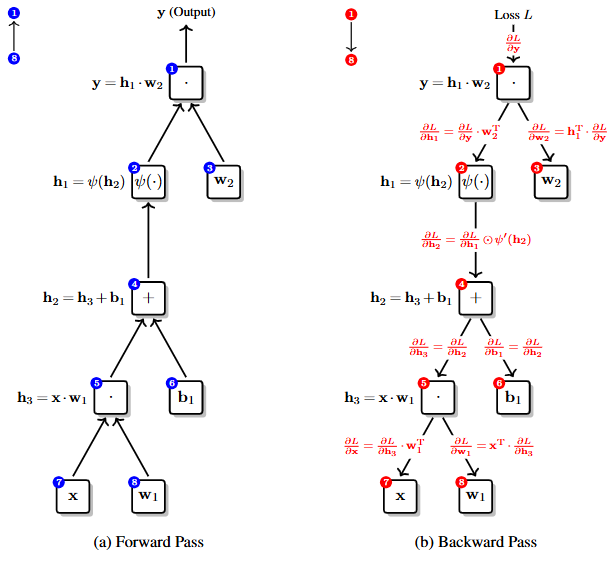

---

### Backpropagation qua Ví Dụ

Cho hàm:

$$\mathbf{y} = h_1 \cdot W_2, \quad h_1 = \psi(h_2), \quad h_2 = h_3 + \mathbf{b}_1, \quad h_3 = \mathbf{x} \cdot W_1 \tag{2.14-2.17}$$

Tính gradient từng nút từ output ngược về input:

$$\frac{\partial L}{\partial \mathbf{y}} = \delta_y \quad \text{(phụ thuộc loss function)} \tag{2.18}$$

$$\frac{\partial L}{\partial h_1} = \frac{\partial L}{\partial \mathbf{y}} \cdot W_2^\top \tag{2.19}$$

$$\frac{\partial L}{\partial W_2} = h_1^\top \cdot \frac{\partial L}{\partial \mathbf{y}} \tag{2.20}$$

$$\frac{\partial L}{\partial h_2} = \frac{\partial L}{\partial h_1} \odot \psi'(h_2) \quad \text{($\odot$ là Hadamard product)} \tag{2.21}$$

$$\frac{\partial L}{\partial h_3} = \frac{\partial L}{\partial \mathbf{b}_1} = \frac{\partial L}{\partial h_2} \tag{2.22, 2.23}$$

$$\frac{\partial L}{\partial \mathbf{x}} = \frac{\partial L}{\partial h_3} \cdot W_1^\top \tag{2.24}$$

$$\frac{\partial L}{\partial W_1} = \mathbf{x}^\top \cdot \frac{\partial L}{\partial h_3} \tag{2.25}$$

Trong đó $\delta_y = \mathbf{y} - \mathbf{y}_{\text{gold}}$ nếu dùng squared loss $L = \frac{1}{2}\|\mathbf{y} - \mathbf{y}_{\text{gold}}\|^2$.

> **Pattern quan trọng trong backprop:**
> - Gradient qua **phép nhân ma trận** $h = x \cdot W$: gradient theo $x$ dùng $W^\top$, gradient theo $W$ dùng $x^\top$
> - Gradient qua **hàm kích hoạt** $h_1 = \psi(h_2)$: nhân element-wise với $\psi'(h_2)$ — đây là lý do ReLU phổ biến ($\psi'$ chỉ là 0 hoặc 1, tính toán rất nhanh)
> - Backpropagation là **tái sử dụng tính toán** của forward pass — chi phí tương đương forward, không tốn thêm nhiều.

---

## Tổng Kết Mục 2.1

```
Perceptron đơn
  = affine transform + activation function
  = bộ phân loại tuyến tính cơ bản

Single-layer neural network
  = nhiều perceptron song song
  = x → xW + b → ψ(·) → y

Multi-layer (deep) neural network
  = xếp chồng nhiều lớp
  = hợp của nhiều hàm
  = Feed-forward Neural Network (FFNN)

Computation graph
  = biểu diễn bằng đồ thị có hướng
  → Forward pass: tính output
  → Backward pass: tính gradient (backpropagation)
```

| Khái niệm | Ý nghĩa |
|---|---|
| Depth | Số lớp → khả năng biểu diễn phức tạp |
| Width | Số nơ-ron/lớp → khả năng biểu diễn rộng |
| Activation function | Thêm phi tuyến → mạng mạnh hơn đơn thuần tuyến tính |
| Backpropagation | Chain rule qua đồ thị tính toán → gradient hiệu quả |

# 2.2 Ví Dụ: Mô Hình Ngôn Ngữ Nơ-ron (Neural Language Modeling)

---

## Language Modeling là gì?

**Language modeling** ước lượng phân phối xác suất trên chuỗi từ. Với chuỗi $w_1\ldots w_m$:

$$\Pr(w_1, \ldots, w_m) = \prod_{i=1}^m \Pr(w_i \mid w_1, \ldots, w_{i-1}) \tag{2.26}$$

Bài toán quy về: **dự đoán từ tiếp theo** dựa trên toàn bộ ngữ cảnh trước đó.

---

## Từ N-gram đến Neural Language Model

**Xấp xỉ cửa sổ ngữ cảnh cố định** (độ dài $n$):

$$\Pr(w_i \mid w_1, \ldots, w_{i-1}) \approx \Pr(w_i \mid w_{i-n+1}, \ldots, w_{i-1}) \tag{2.27}$$

**N-gram language model** ước lượng bằng tần suất tương đối:

$$\Pr(w_i \mid w_{i-n+1}, \ldots, w_{i-1}) = \frac{\text{count}(w_{i-n+1}\ldots w_i)}{\text{count}(w_{i-n+1}\ldots w_{i-1})}$$

**Vấn đề của n-gram:**
- Cần bảng khổng lồ lưu xác suất mọi n-gram
- Dữ liệu cực kỳ sparse khi $n$ lớn — **curse of dimensionality**
- Mỗi từ là thực thể độc lập, không nắm bắt được quan hệ ngữ nghĩa

**Giải pháp:** Mạng nơ-ron mã hóa từ thành **vectơ dày đặc, liên tục** (dense, low-dimensional vectors) → tổng quát hóa tốt hơn trong không gian liên tục.

---

## Biểu Diễn Từ (Word Representations)

### One-hot Representation

Mỗi từ $w = V_k$ trong từ điển $V$ được biểu diễn là vectơ $|V|$ chiều, chỉ có vị trí $k$ bằng 1:

Ví dụ với $V = \{\text{"I", "you", "he", "she", "they"}\}$:

$$\mathbf{1}_{\text{you}} = \begin{bmatrix}0 & 1 & 0 & 0 & 0\end{bmatrix} \tag{2.28}$$

**Nhược điểm:** One-hot vector **không nắm bắt quan hệ ngữ nghĩa** — "cat" và "dog" xa nhau như "cat" và "democracy", dù về mặt ngữ nghĩa chúng gần hơn nhiều.

### Word Embedding (Distributed Representation)

Biến đổi one-hot thành vectơ thực liên tục $\mathbf{e} \in \mathbb{R}^{d_e}$:

$$\mathbf{e} = \mathbf{x} \cdot C \tag{2.29}$$

trong đó $C \in \mathbb{R}^{|V| \times d_e}$ là **embedding matrix** — hàng thứ $k$ là vector của từ $V_k$.

Thực chất $\mathbf{x} \cdot C$ chỉ là **"tra bảng"** (lookup) hàng tương ứng của $C$:

**Ví dụ tính toán** với $C \in \mathbb{R}^{5 \times 3}$:

$$\mathbf{e}(\text{"you"}) = \begin{bmatrix}0&1&0&0&0\end{bmatrix} \cdot \begin{pmatrix}73&12&0.1\\12&0.5&18\\37&0.7&28\\61&0.4&23\\62&11&0.4\end{pmatrix} = \begin{bmatrix}12&0.5&18\end{bmatrix} \tag{2.30}$$

> **Ý nghĩa của word embedding:** Mỗi chiều của $\mathbf{e}$ encode một khía cạnh nào đó của từ (không nhất thiết có thể giải thích được). Các từ có ngữ nghĩa tương tự sẽ có vector gần nhau → mô hình có thể suy luận: nếu "grapes are fruits" thì "peaches are fruits" cũng có xác suất cao vì embedding của "grapes" và "peaches" gần nhau.

---

## Kiến Trúc Feed-Forward Neural Language Model (FFNNLM)

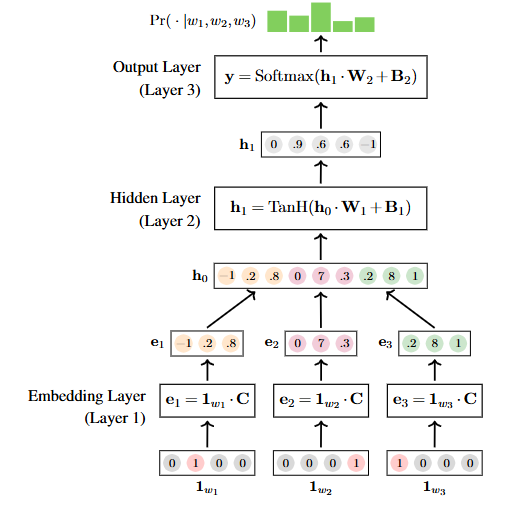

**Input:** $n-1$ từ ngữ cảnh $w_{i-n+1}, \ldots, w_{i-1}$ dạng one-hot.

**Bước 1 — Embedding Layer:**

$$h_0 = [\mathbf{e}_{i-n+1}, \ldots, \mathbf{e}_{i-1}] \quad \text{(concatenate)}$$

Mỗi từ được tra bảng embedding $C$, rồi nối lại thành vectơ $h_0 \in \mathbb{R}^{(n-1)d_e}$.

**Bước 2 — Hidden Layer:**

$$h_1 = \text{TanH}(h_0 \cdot W_1 + B_1) \tag{2.31}$$

$h_1 \in \mathbb{R}^{d_h}$ — vectơ đặc trưng ngữ cảnh.

**Bước 3 — Output Layer:**

$$\Pr(\cdot \mid w_{i-n+1}, \ldots, w_{i-1}) = \text{Softmax}(h_1 \cdot W_2 + B_2) \tag{2.32}$$

Đầu ra là phân phối xác suất trên toàn bộ từ điển $V$ — $y_k = \Pr(V_k \mid w_{i-n+1}, \ldots, w_{i-1})$.

**Tham số của mô hình:**

| Tham số | Kích thước | Vai trò |
|---|---|---|
| $C$ | $\|V\| \times d_e$ | Embedding matrix |
| $W_1$ | $(n-1)d_e \times d_h$ | Hidden layer weights |
| $B_1$ | $d_h$ | Hidden layer bias |
| $W_2$ | $d_h \times \|V\|$ | Output layer weights |
| $B_2$ | $\|V\|$ | Output layer bias |

---

## Forward và Backward Pass

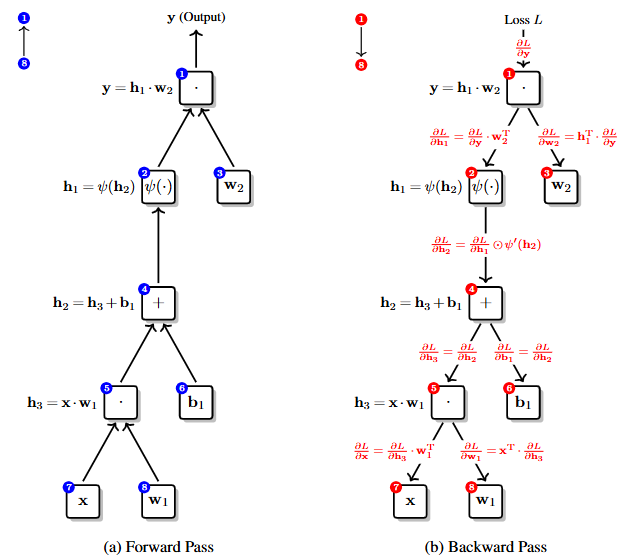

**Forward pass:** Duyệt từ nút 8 (input) → nút 1 (output), tính và lưu giá trị trung gian.

**Backward pass:** Duyệt ngược từ nút 1 → nút 8, lan truyền gradient qua chain rule:

$$\frac{\partial L}{\partial h_1} = \frac{\partial L}{\partial \mathbf{y}} \cdot W_2^\top, \quad \frac{\partial L}{\partial W_2} = h_1^\top \cdot \frac{\partial L}{\partial \mathbf{y}}$$

$$\frac{\partial L}{\partial h_2} = \frac{\partial L}{\partial h_1} \odot \psi'(h_2)$$

$$\frac{\partial L}{\partial \mathbf{x}} = \frac{\partial L}{\partial h_3} \cdot W_1^\top, \quad \frac{\partial L}{\partial W_1} = \mathbf{x}^\top \cdot \frac{\partial L}{\partial h_3}$$

---

## Ba Ưu Điểm của Neural Language Model so với N-gram

**1. Tổng quát hóa qua không gian liên tục:**
Từ có embedding gần nhau → xác suất tương tự → mô hình suy luận được về các cụm từ chưa thấy trong training. N-gram coi mọi surface form là hoàn toàn độc lập.

**2. Kích thước mô hình nhỏ hơn:**
$d_e, d_h$ thường dưới 1000 → số tham số quản lý được. N-gram tăng theo $|V|^n$ — không thể scale.

**3. Biểu diễn ngầm về nghĩa từ:**
Word embedding học được "sense" của từ — các từ đồng nghĩa hoặc cùng ngữ cảnh sẽ có vector gần nhau. N-gram không có cơ chế này.

**Nhược điểm:** Tốn kém tính toán do nhân ma trận nặng → giải pháp: GPU/parallel computing, hoặc phân tán mô hình/dữ liệu.

---

## Tổng Kết Mục 2.2

```
Bài toán: Pr(wᵢ | w₁,...,wᵢ₋₁)

N-gram:  đếm tần suất → sparse, không scale
         ↓ vấn đề
Neural:  one-hot → embedding → hidden → softmax
         ↓ ưu điểm
         - Tổng quát hóa qua word similarity
         - Kích thước mô hình nhỏ hơn
         - Học được quan hệ ngữ nghĩa ẩn

Kiến trúc FFNNLM:
  Input (one-hot)
    → Embedding layer: e = x·C  [lookup table]
    → Concatenate: h₀ = [e₁,...,eₙ₋₁]
    → Hidden: h₁ = TanH(h₀·W₁ + B₁)
    → Output: y = Softmax(h₁·W₂ + B₂)
```

> **Kết nối quan trọng:** Embedding matrix $C$ là nền tảng của toàn bộ NLP hiện đại — Chương 3 sẽ đi sâu vào các phương pháp học word embeddings (Word2Vec, GloVe,...). Kiến trúc FFNNLM ở đây là bước đệm trước khi chuyển sang RNN (Mục 2.3) và Transformer (Chương 4).

# 2.3 Các Kiến Trúc Mô Hình Cơ Bản (Basic Model Architectures)

---

## 2.3.1 Đơn Vị Hồi Quy (Recurrent Units — RNN)

### Lý thuyết

**RNN** được thiết kế để xử lý **dữ liệu tuần tự** (sequential/time-series data). Ý tưởng cốt lõi: duy trì một **trạng thái ẩn** (hidden state) $s_i$ hoạt động như "bộ nhớ" tóm tắt thông tin từ các bước trước.

**Công thức tổng quát:**

$$s_i = \text{RNN}(s_{i-1}, x_i) \tag{2.33}$$

Triển khai đệ quy:

$$\text{RNN}(s_{i-1}, x_i) = \text{RNN}(\text{RNN}(s_{i-2}, x_{i-1}), x_i) = \ldots = \text{RNN}(\text{RNN}(\ldots(\text{RNN}(s_0, x_1), x_2)\ldots, x_{i-1}), x_i) \tag{2.34}$$

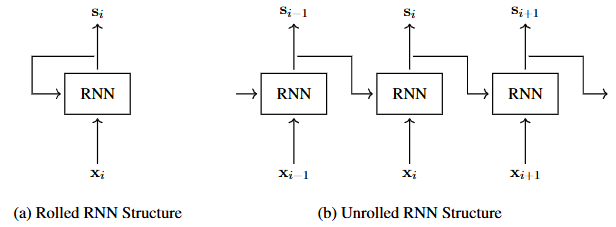

**Rolled vs Unrolled:**
- **Rolled:** biểu diễn gọn, vòng lặp tái sử dụng cùng một đơn vị
- **Unrolled:** triển khai theo thời gian thành mạng feed-forward sâu theo chiều ngang — mỗi bước thời gian là một "lớp", **dùng chung tham số**

> **Kết nối với FFNN:** Unrolled RNN = FFNN sâu theo chiều thời gian. Có thể dùng cùng kỹ thuật tối ưu, nhưng RNN dùng biến thể đặc biệt gọi là **Backpropagation Through Time (BPTT)** — lan truyền gradient ngược qua đồ thị tính toán đã unroll.

**Dạng đơn giản nhất** — RNN một lớp với $s_{i-1}, x_i \in \mathbb{R}^{d_h}$:

$$\text{RNN}(s_{i-1}, x_i) = \psi(s_{i-1} \cdot U + x_i \cdot V) \tag{2.35}$$

Tương đương với single-layer neural network vì:

$$\psi(s_{i-1} \cdot U + x_i \cdot V) = \psi([s_{i-1}, x_i] \cdot W), \quad W = \begin{bmatrix}U\\V\end{bmatrix} \in \mathbb{R}^{2d_h \times d_h} \tag{2.36}$$

**Ưu điểm của RNN:**
- Xử lý được **chuỗi có độ dài thay đổi** (variable-length)
- Ứng dụng tốt cho: dịch máy, nhận dạng giọng nói, language modeling
- Trong thực tế thường dùng làm **sub-component** trong kiến trúc lớn hơn — có thể stack thêm lớp phía trên hidden state $s_i$

---

## 2.3.2 Đơn Vị Tích Chập (Convolutional Units — CNN)

### Lý thuyết

**CNN** lấy cảm hứng từ thị giác sinh học: mỗi nơ-ron chỉ phản ứng với một **vùng cục bộ** (receptive field) của đầu vào, thay vì toàn bộ. Do đó CNN là mô hình **kết nối cục bộ** — hiệu quả hơn FFNN về số tham số.

**Phép tích chập 1D** — filter kích thước $r$, tại vị trí $i$:

$$\upsilon = \text{Conv}(x_{[i, i+r-1]}, W) = x_{[i, i+r-1]} \cdot W = \sum_{k=0}^{r-1} x_{i+k} \cdot W_k \tag{2.37}$$

**Trượt filter** với stride $s$:

$$\upsilon_i = \text{Conv}(x_{[\text{stride}\times i,\ \text{stride}\times i + r - 1]}, W) \tag{2.38}$$

Chuỗi đầu vào $x_1\ldots x_m$ → chuỗi đầu ra $\upsilon_1\ldots\upsilon_{\lfloor m/\text{stride}\rfloor}$.

**Sau khi áp dụng activation function:**

$$[h_1, \ldots, h_{m_k}] = \psi([\upsilon_1, \ldots, \upsilon_{m_k}]) \tag{2.39}$$

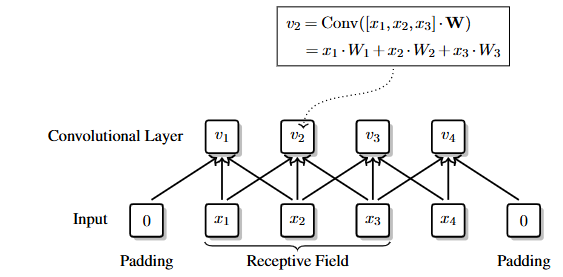

**Hai kỹ thuật quan trọng:**

**Parameter sharing (weight sharing):** Cùng bộ tham số $W$ dùng cho mọi vị trí trong chuỗi → **số tham số ít hơn nhiều** so với FFNN.

**Padding:** Thêm giá trị giả (thường là 0) vào hai đầu chuỗi để filter luôn có đủ input → giữ nguyên độ dài đầu ra.

### Pooling Layer

**Pooling** là hàm aggregation không có tham số, thực hiện **downsampling**:

- **Max pooling:** lấy giá trị lớn nhất trong receptive field
- **Average pooling:** lấy trung bình trong receptive field

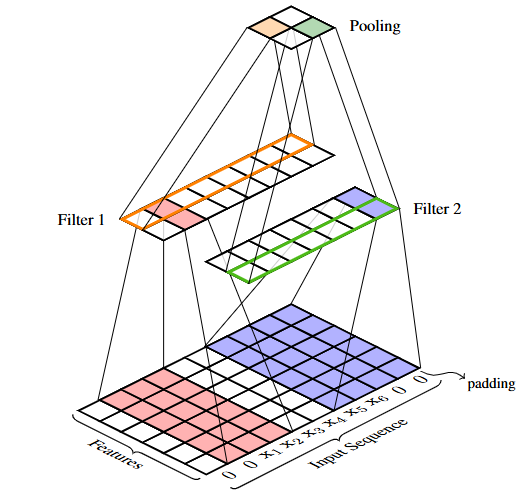

**Lợi ích của overlapping receptive fields:** Các vùng tiếp nhận khác nhau có thể chồng lên nhau — giảm mất thông tin khi đặc trưng cấp thấp đóng góp vào nhiều đặc trưng cấp cao.

**Ưu điểm của CNN:**
- Hiệu quả tham số nhờ weight sharing
- Nắm bắt được đặc trưng **cục bộ** và **phân cấp** (hierarchical features)
- Scale tốt hơn FFNN về độ phức tạp tính toán

---

## 2.3.3 Đơn Vị Cổng (Gate Units)

### Lý thuyết

**Gate** kiểm soát **lượng thông tin** được truyền qua — hoạt động như van điều tiết luồng dữ liệu.

**Ý tưởng:** Thay vì truyền nguyên $s_{i-1}$ vào bước tiếp theo, ta **lọc** xem phần nào cần giữ, phần nào cần quên.

**Gating vector** $\mathbf{z} \in [0,1]^{d_h}$:
- $z_k = 0$: quên hoàn toàn chiều $k$
- $z_k = 1$: giữ nguyên hoàn toàn chiều $k$

**Hai cách định nghĩa gate:**

$$\text{Gate}(\mathbf{z}, s_{i-1}) = \mathbf{z} \odot s_{i-1} \tag{2.40}$$

$$\text{Gate}(\mathbf{z}, s_{i-1}) = (1 - \mathbf{z}) \odot s_{i-1} \tag{2.41}$$

($\odot$ = element-wise multiplication — tích Hadamard)

**Tính $\mathbf{z}$ — learnable gate:**

$$\mathbf{z} = \text{Sigmoid}(s_{i-1} \cdot W_1 + x_i \cdot W_2 + \mathbf{b}) \tag{2.42}$$

Sigmoid đảm bảo $z_k \in (0,1)$ — gate **học được** trong quá trình training.

> **Tại sao cần gate?** RNN đơn giản (2.35) khó học được phụ thuộc dài hạn do **vanishing gradient** — gradient triệt tiêu khi lan truyền ngược qua nhiều bước thời gian. Gate cho phép mô hình **chủ động kiểm soát** thông tin nào được nhớ hay quên, giải quyết vấn đề này. LSTM và GRU (Chương 4) là các kiến trúc gate nổi tiếng nhất.

---

## 2.3.4 Đơn Vị Chuẩn Hóa (Normalization Units)

### Lý thuyết

**Vấn đề:** Trong mạng nơ-ron sâu, phân phối của activation có thể rất khác nhau giữa các lớp hoặc giữa các đặc trưng. Khởi tạo ngẫu nhiên có thể khiến một số đặc trưng có giá trị quá lớn → mô hình bị bias về phía chúng.

**Giải pháp — Chuẩn hóa:**

$$\text{Normalize}(\mathbf{s}) = \boldsymbol{\alpha} \odot \frac{\mathbf{s} - \boldsymbol{\mu}}{\boldsymbol{\sigma} + \varepsilon} + \boldsymbol{\beta} \tag{2.43}$$

trong đó:
- $\boldsymbol{\mu} \in \mathbb{R}^n$, $\boldsymbol{\sigma} \in \mathbb{R}^n$: mean và standard deviation của $\mathbf{s}$
- $\varepsilon$: hằng số nhỏ để ổn định số (tránh chia cho 0)
- $\boldsymbol{\alpha}, \boldsymbol{\beta} \in \mathbb{R}^n$: tham số học được (scale và shift)

**Tính $\mu_k$ và $\sigma_k$** trên tập $\Omega_k$:

$$\mu_k = \frac{1}{|\Omega_k|}\sum_{s \in \Omega_k} s \tag{2.44}$$

$$\sigma_k = \sqrt{\frac{1}{|\Omega_k|}\sum_{s \in \Omega_k}(s - \mu_k)^2} \tag{2.45}$$

**Các phương pháp chuẩn hóa khác nhau ở cách định nghĩa $\Omega_k$:**

| Phương pháp | Định nghĩa $\Omega_k$ | Ứng dụng phổ biến |
|---|---|---|
| **Batch Norm** | Cùng đặc trưng, khác sample | CNN, FFNN |
| **Layer Norm** | Cùng lớp, cùng sample | RNN, Transformer |
| **Instance Norm** | Cùng sample, cùng kênh | Style transfer |
| **Group Norm** | Nhóm kênh, cùng sample | Khi batch nhỏ |

**Lợi ích:**
- Đưa đặc trưng về cùng scale → các đặc trưng có thể so sánh được
- **Ổn định quá trình training**, cải thiện tốc độ hội tụ
- Cho phép dùng learning rate lớn hơn

> **Lưu ý thuật ngữ:** Trong deep learning, "normalization" thực ra là **standardization** (trừ mean, chia std, không ép về [0,1]). Hai thuật ngữ dùng thay thế nhau trong cuốn sách này.

---

## 2.3.5 Đơn Vị Phần Dư (Residual Units)

### Lý thuyết

**Vấn đề của mạng rất sâu:**
- **Vanishing/exploding gradient:** gradient triệt tiêu hoặc bùng nổ khi lan truyền qua nhiều lớp
- **Degradation problem:** thêm lớp không cải thiện, thậm chí làm giảm hiệu suất
- Các lớp trên không truy cập được biểu diễn trung gian từ lớp dưới

**Giải pháp — Residual Connection (Skip Connection):**

$$y = F(x) + x \tag{2.46}$$

$$x_{l+1} = F(x_l) + x_l \tag{2.47}$$

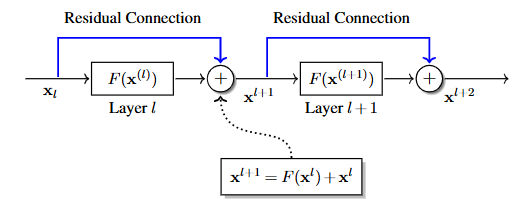

**Ý tưởng:** Thay vì học trực tiếp ánh xạ $x \to y$, mạng chỉ cần học **phần dư** $F(x) = y - x$. Nếu identity là ánh xạ tối ưu, mô hình chỉ cần đẩy $F(x) \to 0$ — dễ hơn nhiều.

**Tại sao residual connection hoạt động?**

```
Không có residual:
x → Layer 1 → Layer 2 → ... → Layer L → y
Gradient phải đi qua tất cả L lớp ngược lại

Có residual connection:
x → Layer 1 → Layer 2 → ... → Layer L → y
↑_______________skip_____________________↑
Gradient có "đường tắt" qua skip connections
→ không bị triệt tiêu
```

**Lợi ích:**
- Gradient có **đường đi trực tiếp** từ output về input qua skip connection → giảm vanishing gradient
- Các lớp trên có thể **truy cập trực tiếp** biểu diễn từ lớp dưới
- Cho phép huấn luyện mạng **rất sâu** (hàng trăm lớp) — ResNet có 152 lớp
- Residual connection là thành phần **cốt lõi** của Transformer (Chương 4)

---

## Tổng Kết Mục 2.3

| Đơn vị | Ý tưởng cốt lõi | Ưu điểm | Ứng dụng |
|---|---|---|---|
| **RNN** | Trạng thái ẩn tích lũy thông tin theo thời gian | Xử lý chuỗi độ dài thay đổi | Dịch máy, LM, NER |
| **CNN** | Filter cục bộ trượt qua chuỗi | Weight sharing, hiệu quả tham số | Phân loại văn bản, NER |
| **Gate** | Kiểm soát luồng thông tin bằng $\mathbf{z} \in [0,1]^{d_h}$ | Giải quyết vanishing gradient, học phụ thuộc dài | LSTM, GRU |
| **Normalization** | Chuẩn hóa activation về cùng scale | Ổn định training, hội tụ nhanh | Mọi mạng sâu |
| **Residual** | Skip connection: $x_{l+1} = F(x_l) + x_l$ | Gradient flow tốt, train mạng rất sâu | ResNet, Transformer |

> **Kết nối với Transformer:** Bốn đơn vị cuối — Gate, Normalization, Residual, và Attention (sẽ học ở Chương 4) — chính là bốn thành phần xây dựng nên kiến trúc Transformer hiện đại. Hiểu rõ từng cái ở đây là nền tảng thiết yếu.

# 2.4 Huấn Luyện Mạng Nơ-ron (Training Neural Networks)

---

## 2.4.1 Gradient Descent và các Biến Thể

### Công thức cập nhật cơ bản

$$\theta_{t+1} = \theta_t - \eta \cdot \frac{\partial L(\theta_t)}{\partial \theta_t} \tag{2.49}$$

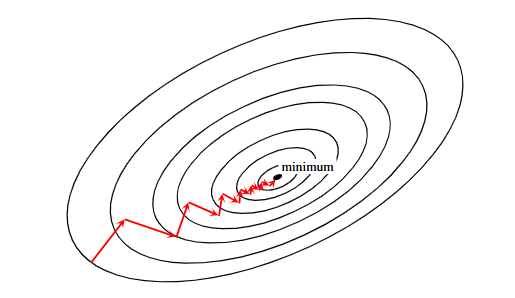

$\eta$ là **learning rate** — kiểm soát độ lớn mỗi bước đi. Thường điều chỉnh trong quá trình training (xem Mục 2.4.4).

---

### Các Biến Thể Gradient Descent

#### 1. Momentum

**Ý tưởng:** Duy trì "đà" của các bước trước, giảm dao động, tăng tốc theo hướng nhất quán.

**Classic Momentum (Polyak, 1964):**

$$\theta_{t+1} = \theta_t + v_t \tag{2.50}$$

$$v_t = \lambda \cdot v_{t-1} - \eta \cdot \frac{\partial L(\theta_t)}{\partial \theta_t} \tag{2.51}$$

**Nesterov Momentum** — tính gradient tại vị trí **dự kiến** (nhìn trước):

$$v_t = \lambda \cdot v_{t-1} - \eta \cdot \frac{\partial L(\theta_t + \lambda \cdot v_{t-1})}{\partial \theta_t} \tag{2.52}$$

> **Tại sao Nesterov tốt hơn?** Classic momentum tính gradient tại vị trí hiện tại rồi mới nhảy. Nesterov "nhìn trước" vị trí sau khi áp momentum, tính gradient ở đó → tránh overshoot tốt hơn khi gần cực tiểu.

---

#### 2. Adaptive Gradient Descent

**Vấn đề của SGD thuần:** Cùng learning rate cho mọi tham số — không tối ưu vì một số tham số cập nhật thường xuyên, một số ít.

**AdaGrad** — scale down learning rate của tham số cập nhật nhiều, scale up của tham số cập nhật ít:

$$G_t = \sum_{i=1}^t \left(\frac{\partial L(\theta_i)}{\partial \theta_i}\right)^\top \cdot \frac{\partial L(\theta_i)}{\partial \theta_i} \tag{2.54}$$

$$\theta_{t+1} = \theta_t - \frac{\eta}{\sqrt{\text{diag}(G_t) + \varepsilon}} \odot \frac{\partial L(\theta_t)}{\partial \theta_t} \tag{2.55}$$

**Nhược điểm của AdaGrad:** $G_t$ tích lũy mãi → learning rate giảm về 0, training dừng sớm.

**AdaDelta / RMSProp** — khắc phục bằng cách dùng **moving average có trọng số** thay vì tổng tích lũy:

$$g^2_t = \sigma \cdot g^2_{t-1} + (1-\sigma) \cdot \left(\frac{\partial L(\theta_t)}{\partial \theta_t} \odot \frac{\partial L(\theta_t)}{\partial \theta_t}\right) \tag{2.56}$$

$$\theta_{t+1} = \theta_t - \frac{\eta}{\sqrt{g^2_t + \varepsilon}} \odot \frac{\partial L(\theta_t)}{\partial \theta_t} \tag{2.57}$$

$\sigma < 1$ là decay factor — gradient "cũ" mờ dần, gradient "mới" quan trọng hơn. $\sqrt{g^2_t + \varepsilon}$ chính là **RMS** (root mean square) của gradient.

---

#### 3. Adam (Adaptive Moment Estimation)

**Adam** kết hợp cả momentum lẫn adaptive gradient — optimizer phổ biến nhất hiện nay.

**Moment thứ nhất** (trung bình gradient — tương đương momentum):

$$m_t = \beta_1 \cdot m_{t-1} + (1-\beta_1) \cdot \frac{\partial L(\theta_t)}{\partial \theta_t} \tag{2.58}$$

**Moment thứ hai** (trung bình bình phương gradient — tương đương adaptive scale):

$$v_t = \beta_2 \cdot v_{t-1} + (1-\beta_2) \cdot \left(\frac{\partial L(\theta_t)}{\partial \theta_t} \odot \frac{\partial L(\theta_t)}{\partial \theta_t}\right) \tag{2.59}$$

**Vấn đề bias:** $m_0 = v_0 = 0$ → ở các bước đầu, $m_t$ và $v_t$ bị kéo về 0. **Bias correction:**

$$\hat{m}_t = \frac{m_t}{1-\beta_1^t} \tag{2.60}$$

$$\hat{v}_t = \frac{v_t}{1-\beta_2^t} \tag{2.61}$$

**Công thức cập nhật cuối:**

$$\theta_{t+1} = \theta_t - \eta \cdot \frac{\hat{m}_t}{\sqrt{\hat{v}_t} + \varepsilon} \tag{2.62}$$

**Giá trị mặc định phổ biến:** $\beta_1 = 0.9$, $\beta_2 = 0.999$, $\varepsilon = 10^{-8}$.

> **Tóm tắt so sánh các optimizer:**
>
> | Optimizer | Ý tưởng cốt lõi | Ưu điểm | Nhược điểm |
> |---|---|---|---|
> | SGD | Gradient thuần | Đơn giản | Chậm, noisy |
> | Momentum | Duy trì đà | Giảm zigzag | Thêm hyperparameter |
> | AdaGrad | Scale per-param | Tốt cho sparse features | LR → 0 sớm |
> | RMSProp | Moving avg gradient² | Ổn định hơn AdaGrad | Cần chọn decay |
> | **Adam** | **Momentum + RMSProp** | **Hiệu quả, ít tune** | **Đôi khi không tổng quát tốt** |

**Điều kiện dừng training:** Đặt số bước/epoch tối đa, hoặc dùng **early stopping** — dừng khi validation loss tăng (xem Mục 2.5.3).

---

## 2.4.2 Batching

**Ba chế độ batching:**

| Phương pháp | Batch size | Ưu điểm | Nhược điểm |
|---|---|---|---|
| **SGD** | 1 sample | Cập nhật thường xuyên, thoát local minima | Gradient noisy, không tận dụng GPU |
| **BGD** | Toàn bộ $D$ | Gradient chính xác | Chậm, tốn bộ nhớ |
| **Mini-batch GD** | $m \ll |D|$ | Cân bằng tốc độ và độ chính xác | Cần chọn batch size |

**Công thức loss mini-batch:**

$$L(\theta) = \frac{1}{|S|} \sum_{(x, y_{\text{gold}}) \in S} L(F_\theta(x), y_{\text{gold}}) \tag{2.65}$$

**Batching như ma trận hóa (vectorization):**

Thay vì gọi forward/backward $m$ lần riêng lẻ, gộp toàn batch thành ma trận:

$$X = \begin{pmatrix}x^{(i_1)}\\\vdots\\x^{(i_m)}\end{pmatrix}, \quad Y_{\text{gold}} = \begin{pmatrix}y^{(i_1)}_{\text{gold}}\\\vdots\\y^{(i_m)}_{\text{gold}}\end{pmatrix} \tag{2.66, 2.67}$$

$$Y_\theta = F_\theta(X), \quad L(\theta) = \frac{1}{m} \cdot L(Y_\theta, Y_{\text{gold}}) \tag{2.68, 2.69}$$

Một lần forward/backward duy nhất cho toàn batch → **tận dụng tối đa GPU** (parallel matrix operations).

---

## 2.4.3 Khởi Tạo Tham Số (Parameter Initialization)

Vì hàm mục tiêu **non-convex** với nhiều local minima, khởi tạo tham số ảnh hưởng lớn đến kết quả.

### Các Phương Pháp Khởi Tạo

**1. Constant Initialization:** Gán cùng giá trị cho mọi tham số → tất cả hidden unit cập nhật giống nhau → mạng không học được gì. **Không dùng trong thực tế.**

**2. Random từ phân phối:** Lấy ngẫu nhiên từ Uniform hoặc Gaussian, ví dụ $\mathcal{U}(-0.1, 0.1)$. Đơn giản, hiệu quả cho nhiều bài toán cơ bản.

**3. LeCun Initialization** — xét chiều đầu vào $d_{\text{in}}$:

$$W \in \mathbb{R}^{d_{\text{in}} \times d_{\text{out}}} \sim \mathcal{U}\!\left(-\frac{1}{\sqrt{d_{\text{in}}}},\ \frac{1}{\sqrt{d_{\text{in}}}}\right) \tag{2.70}$$

**4. Xavier / Glorot Initialization** — xét cả $d_{\text{in}}$ và $d_{\text{out}}$, ổn định variance qua các lớp:

$$W \sim \mathcal{U}\!\left(-\sqrt{\frac{6}{d_{\text{in}}+d_{\text{out}}}},\ \sqrt{\frac{6}{d_{\text{in}}+d_{\text{out}}}}\right) \tag{2.71}$$

> **Lý do Xavier xét cả $d_{\text{in}}$ và $d_{\text{out}}$:** Đảm bảo variance của activation **không tăng hay giảm** qua các lớp — giảm vanishing/exploding gradient ngay từ đầu. Thiết kế cho Sigmoid/Tanh.

**5. Khởi tạo cho mạng rất sâu** — thêm hệ số phụ thuộc độ sâu $l$:

$$W \sim \mathcal{U}\!\left(-\alpha_s^l \cdot \sqrt{\frac{6}{d_{\text{in}}+d_{\text{out}}}},\ \alpha_s^l \cdot \sqrt{\frac{6}{d_{\text{in}}+d_{\text{out}}}}\right) \tag{2.72}$$

> **Lưu ý thực tế:**
> - ReLU → dùng **He initialization** (khác Xavier vì ReLU không đối xứng)
> - Transformer → nhiều phương pháp chuyên biệt: T-Fixup, Admin,...
> - Chạy nhiều lần với random seed khác nhau, chọn kết quả tốt nhất

---

## 2.4.4 Learning Rate Scheduling

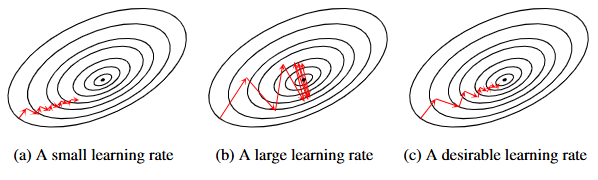

**Vấn đề:** LR lớn → overshoot; LR nhỏ → hội tụ chậm. Chiến lược tốt: **LR lớn khi xa minimum, nhỏ dần khi gần**.

### Các Phương Pháp Scheduling

**Fixed Learning Rate:** Không thay đổi. Đơn giản, chỉ dùng để prototyping nhanh.

**Learning Rate Decay:** Giảm dần theo schedule. Các dạng phổ biến:

| Tên | Công thức | Đặc điểm |
|---|---|---|
| Exponential Decay | $\eta_{n_t} = \eta_0 \cdot \lambda^{n_t/n_{\text{decay}}}$ | Giảm mũ liên tục |
| Drop Exponential | $\eta_{n_t} = \eta_0 \cdot \lambda^{\lfloor n_t/n_{\text{decay}}\rfloor}$ | Giảm theo bậc thang |
| Inverse Time Decay | $\eta_{n_t} = \frac{\eta_0}{1 + \lambda \cdot n_t/n_{\text{decay}}}$ | Giảm chậm dần |
| Cosine Decay | $\eta_{n_t} = \eta_0 \cdot \frac{1+\cos(\pi \cdot n_t/n_{\text{decay}})}{2}$ | Mượt mà, phổ biến |

**Warmup + Decay (Vaswani et al., 2017)** — chuẩn de facto cho Transformer:

$$\eta_{n_t} = \eta_0 \cdot \min\!\left(\left(\frac{n_t}{n_{\text{decay}}}\right)^{-0.5},\ \frac{n_t}{n_{\text{decay}}} \cdot (n_{\text{warmup}})^{-1.5}\right) \tag{2.73}$$

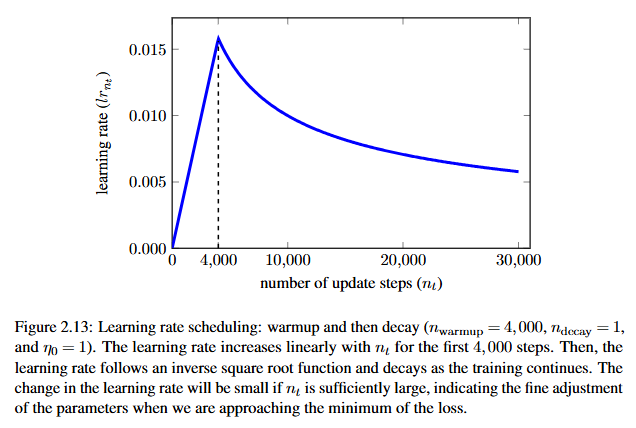

**Tại sao cần warmup?**
- Lúc đầu tham số ngẫu nhiên → gradient rất noisy → LR lớn ngay sẽ gây không ổn định
- Warmup cho phép mô hình "tìm phương hướng" trước khi tăng tốc

> **Lưu ý thực tế:** Batch size lớn hơn thường cần LR lớn hơn tương ứng. Chọn LR schedule là bài toán empirical — thường cần thử nhiều lần.

---

## Tổng Kết Mục 2.4

```
Training pipeline:

Khởi tạo θ (Xavier/He/...)
    ↓
Lặp:
  1. Sample mini-batch S từ D
  2. Forward pass: tính Y_θ = F_θ(X)
  3. Tính loss: L(θ) = mean(L(Y_θ, Y_gold))
  4. Backward pass (backprop): tính ∂L/∂θ
  5. Cập nhật θ theo optimizer (SGD/Adam/...)
  6. Điều chỉnh LR theo schedule
    ↓
Dừng khi: max steps / early stopping
```

| Thành phần | Lựa chọn phổ biến |
|---|---|
| **Optimizer** | Adam ($\beta_1=0.9$, $\beta_2=0.999$) |
| **Batch size** | 32–512 (tùy GPU memory) |
| **Initialization** | Xavier (Sigmoid/Tanh), He (ReLU) |
| **LR Schedule** | Warmup + cosine/inverse decay |
| **Stopping** | Early stopping trên validation set |

# 2.5 Các Phương Pháp Regularization

Regularization giải quyết vấn đề **overfitting** — mô hình học tốt trên training data nhưng kém trên unseen data. Mục này trình bày nhiều phương pháp, từ cổ điển đến hiện đại.

---

## 2.5.1 L1 và L2 Regularization (Weight Decay)

**Ý tưởng chung** — thêm penalty term vào loss:

$$L_{\text{reg}}(\theta) = L(\theta) + \lambda \cdot R(\theta) \tag{2.74}$$

**L1 norm** ($R(\theta) = \|\theta\|_1$): khuyến khích **sparsity** — nhiều tham số về đúng 0.

**L2 norm** ($R(\theta) = \|\theta\|_2^2$): **"smoothing"** — tất cả tham số nhỏ nhưng không nhất thiết bằng 0. Còn gọi là **weight decay** vì mỗi bước gradient descent co tham số lại:

$$\theta_{t+1} = \theta_t - \eta\frac{\partial L}{\partial \theta_t} - \eta\lambda\theta_t = (1-\eta\lambda)\theta_t - \eta\frac{\partial L}{\partial \theta_t}$$

Hệ số $(1-\eta\lambda) < 1$ "decay" tham số mỗi bước.

> **Ý nghĩa Bayesian:** Regularization tương đương với đưa prior vào tham số — L2 tương ứng Gaussian prior, L1 tương ứng Laplace prior. Đây là framework tổng quát để inject prior knowledge vào training.

---

## 2.5.2 Dropout

### Vấn đề — Co-adaptation

Trong lớp nhiều nơ-ron, các nơ-ron **cùng nhau học** để phối hợp — co-adaptation. Trong training điều này tốt (tạo higher-order features), nhưng trong testing lại xấu: thay đổi nhỏ ở input ảnh hưởng toàn bộ nơ-ron → kém generalization.

### Giải pháp — Dropout

**Ý tưởng:** Mỗi bước training, **ngẫu nhiên tắt** một số nơ-ron → mỗi nơ-ron phải học hoạt động độc lập, không phụ thuộc vào "đồng nghiệp" cố định.

**Mask vector** $M_{\text{drop}} \in \{0,1\}^n$, mỗi entry = 1 với xác suất $\rho$:

$$\mathbf{y} = M_{\text{drop}} \odot \psi(\mathbf{x} \cdot W + B) \tag{2.77}$$

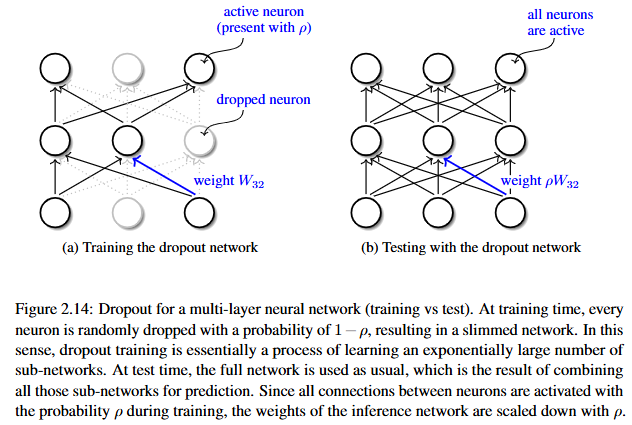

### Training vs Testing

**Training:** Mỗi forward/backward pass dùng $M_{\text{drop}}$ ngẫu nhiên khác nhau → thực chất training $2^n$ sub-network dùng chung tham số.

**Testing:** Dùng toàn bộ nơ-ron, nhưng **scale weights xuống** $\rho$ để bù đắp (khi training chỉ $\rho$ nơ-ron active):

$$\mathbf{y} = \psi(\mathbf{x} \cdot \rho W + \rho B) \tag{2.78}$$

**Inverted Dropout** (cách cài đặt phổ biến hơn) — scale up trong training, giữ nguyên khi test:

$$\mathbf{y} = M_{\text{drop}} \odot \psi\!\left(\mathbf{x} \cdot \frac{1}{\rho}W + \frac{1}{\rho}B\right) \tag{2.79}$$

Nhân $\frac{1}{\rho}W$ với $\rho$ (kỳ vọng của mask) = $W$ → test không cần thay đổi gì.

> **Hai góc nhìn về dropout:**
> 1. **Ensemble learning:** Training nhiều sub-network dùng chung tham số → test là trung bình ensemble
> 2. **Noisy training:** Mỗi nơ-ron học trong môi trường nhiễu (không biết "đồng nghiệp" nào sẽ có mặt)

---

## 2.5.3 Early Stopping

**Ý tưởng:** Dừng training khi validation performance bắt đầu xấu đi — tránh overfit.

**Cơ sở lý thuyết:** Early stopping có hiệu ứng tương tự L2 regularization (giới hạn tham số trong vùng nhỏ).

**Các điều kiện dừng phổ biến:**
- Sự thay đổi performance **dưới ngưỡng** trong $k$ bước liên tiếp
- Sự thay đổi tham số **dưới ngưỡng** trong $k$ bước
- **Trung bình** performance qua $k$ bước bắt đầu giảm
- **Giá trị tốt nhất** qua $k$ bước bắt đầu xấu đi

**Vấn đề thực tế:** Validation curve không phải U-shape hoàn hảo — thường dao động, có nhiều local minima → khó xác định khi nào thực sự "dừng tốt nhất".

**Checkpoint averaging** (tốt hơn chọn một điểm dừng đơn lẻ):
- Lưu checkpoint mỗi $k$ bước
- Model cuối = **trung bình tham số** của $m$ checkpoint cuối
- Hoặc dùng ensemble methods phức tạp hơn

---

## 2.5.4 Làm Mịn Phân Phối Đầu Ra (Smoothing Output Probabilities)

**Vấn đề:** Training thường dùng one-hot labels — mô hình bị ép output xác suất 1 cho đúng một từ/lớp, 0 cho tất cả còn lại. Điều này quá "cứng" → overconfident → kém generalization.

### Ba Phương Pháp Làm Mịn

**1. Additive Smoothing** — thêm $\alpha$ vào mọi count:

$$\hat{p}_k = \frac{s_k + \alpha}{\sum_{k=1}^n (s_k + \alpha)} \tag{2.81}$$

$\alpha = 0$: giữ nguyên; $\alpha \to \infty$: phân phối đều $\frac{1}{n}$.

**2. Temperature Scaling (Boltzmann):**

$$\hat{p}_k = \frac{\exp(s_k/\beta)}{\sum_{k=1}^n \exp(s_k/\beta)} \tag{2.82}$$

$\beta$ nhỏ → phân phối nhọn (confident); $\beta$ lớn → phân phối phẳng (uncertain). Dùng khi cần kiểm soát độ tự tin của mô hình.

**3. Label Smoothing** — nội suy với phân phối đều:

$$\hat{p}_k = (1-\varepsilon) \cdot p_k + \frac{\varepsilon}{n} \tag{2.85}$$

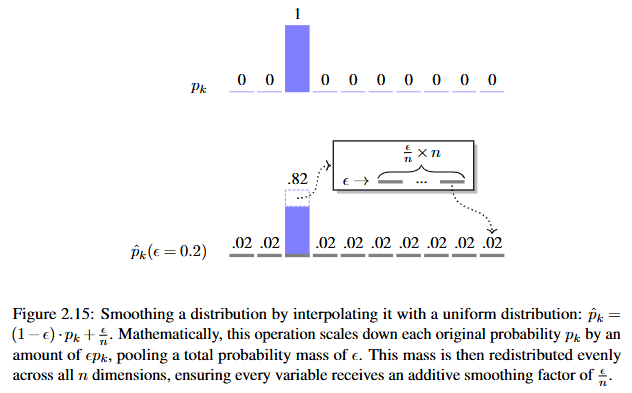

Ví dụ với $n=10$, $\varepsilon=0.2$: nhãn đúng từ 1.0 xuống 0.82, các nhãn khác từ 0 lên 0.02.

**Label Smoothing trong NLP:** Thay vì training với one-hot "peaches are fruits → 1.0", dùng phân phối mềm hơn → mô hình không overfit vào label cứng → generalize tốt hơn.

---

## 2.5.5 Training với Nhiễu (Training with Noise)

**Triết lý chung:** Mô hình tốt phải hoạt động được trong **điều kiện không lý tưởng** → training với nhiễu giúp mô hình robust hơn.

### Gaussian Noise

Thêm noise vào activation $\mathbf{x} \in \mathbb{R}^n$:

$$\mathbf{x}_{\text{noise}} = \mathbf{x} + \mathbf{g}, \quad \mathbf{g} \sim \mathcal{N}(\boldsymbol{\mu}, \text{diag}(\boldsymbol{\sigma}^2)) \tag{2.86, 2.87}$$

### Các Vị Trí Có Thể Inject Noise

| Vị trí | Công thức | Tác dụng |
|---|---|---|
| **Input** | $\mathbf{y} = \psi((\mathbf{x}+g_{\text{input}}) \cdot W + B)$ | Robust với input biến đổi |
| **Activation/Output** | $\mathbf{y} = \psi(\mathbf{x} \cdot W + B) + g_{\text{output}}$ | Smooth hidden representation |
| **Weights** | $\mathbf{y} = \psi(\mathbf{x} \cdot (W+g_w) + B)$ | Regularize tham số |
| **Gradient** | $\frac{\partial L}{\partial W} = \mathbf{x}^\top \cdot \left(\frac{\partial L}{\partial \mathbf{y}} \odot \psi'(s)\right) + g_{\text{gradient}}$ | Dễ gradient flow hơn |

> **Lưu ý:** Noise chỉ có mặt trong **training** — test dùng mô hình gốc không có noise. Dropout là trường hợp đặc biệt của noisy training (mask = binary noise trên activation).

### Kết Nối với Data Augmentation

Training với noise = tạo ra **vô số sample mới** từ cùng một sample gốc → mở rộng training data hiệu quả.

**Data Augmentation trong NLP** — tạo sample mới từ sample gốc:

| Phương pháp | Mô tả |
|---|---|
| **Thay từ đồng nghĩa** | "big" → "large" |
| **Hoán đổi từ** | "I like cats" → "I cats like" |
| **Xóa/chèn từ** | Bỏ bớt hoặc thêm từ không quan trọng |
| **Back-translation** | Dịch A→B→A để tạo paraphrase |
| **Perturbation trong latent space** | Thay word vector bằng vector gần trong không gian embedding |

**Adversarial Training** — tạo sample cố tình đánh lừa mô hình:
1. **Attack:** Tìm sample $x'$ gần $x$ nhưng mô hình dự đoán sai
2. **Defense:** Train mô hình đúng trên $x'$

Thách thức trong NLP: thay một từ có thể đổi nghĩa hoàn toàn → khó tạo adversarial sample tự nhiên.

---

## Tổng Kết Mục 2.5

| Phương pháp | Cơ chế | Khi nào dùng |
|---|---|---|
| **L1/L2** | Penalty trên tham số | Luôn dùng như baseline |
| **Dropout** | Ngẫu nhiên tắt nơ-ron | FFNN, RNN (ít dùng cho Transformer) |
| **Early Stopping** | Dừng theo validation | Luôn dùng kèm checkpoint |
| **Label Smoothing** | Làm mịn one-hot labels | Classification, language modeling |
| **Noise Injection** | Thêm nhiễu vào input/hidden/weight | Tăng robustness |
| **Data Augmentation** | Tạo thêm training sample | Khi data ít |

> **Nguyên tắc chung:** Regularization = ngăn mô hình "nhớ" quá chính xác training data bằng cách **tạo ra sự không chắc chắn có kiểm soát** trong quá trình training — dù là penalty trên tham số, dropout nơ-ron, làm mịn label, hay thêm noise.

# 2.6 Học Không Giám Sát và Auto-encoder

---

## Bối Cảnh

**Học không giám sát (Unsupervised Learning):** Khám phá cấu trúc ẩn trong dữ liệu **không có nhãn**. Ở đây ta tập trung vào **representation learning** — học cách ánh xạ đối tượng từ không gian chiều cao xuống vectơ đặc trưng chiều thấp.

**Thách thức:** Không có ground-truth label → phải tạo **supervisory signal từ chính dữ liệu**.

**Giải pháp — Auto-encoder:** Học nén và tái tạo lại input → tín hiệu huấn luyện tự nhiên là **reconstruction loss**.

**Chức năng:** Auto-encoder bắt encoder phải hiểu dữ liệu -> làm downstream task trong nlp tiền thân của các mô hình pretrained language model (PLM).

> **Kết nối với PCA:** PCA là trường hợp tuyến tính — tìm chiều có variance lớn nhất. Auto-encoder là **tổng quát hóa phi tuyến** của PCA dùng mạng nơ-ron.

---

## Auto-encoder Cơ Bản (Undercomplete Auto-encoder)

### Kiến Trúc

**Encoder:** Nén input xuống code chiều thấp (bottleneck):

$$h = \text{Enc}(x) \tag{2.93}$$

**Decoder:** Tái tạo input từ code:

$$\tilde{x} = \text{Dec}(h) \tag{2.94}$$

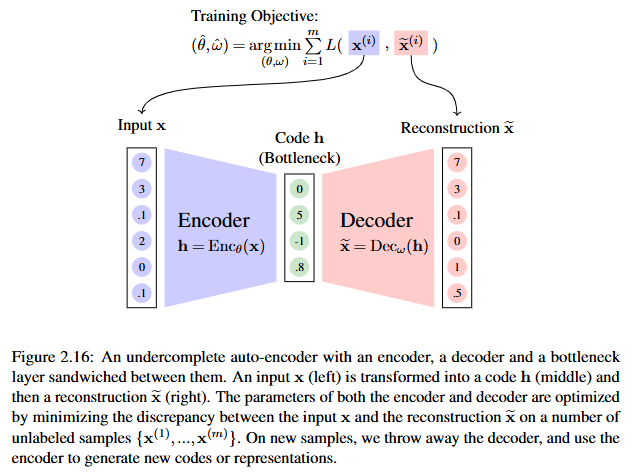

**Hàm mục tiêu:**

$$(\hat{\theta}, \hat{\omega}) = \arg\min_{(\theta,\omega)} \sum_{i=1}^m L\!\left(x^{(i)},\ \text{Dec}_\omega(\text{Enc}_\theta(x^{(i)}))\right) \tag{2.95}$$

$L(\cdot)$ là **reconstruction loss** — ví dụ MSE hoặc cross-entropy.

**Bottleneck** là điểm mấu chốt: $h$ chiều nhỏ hơn $x$ → encoder **buộc phải nén** thông tin quan trọng, không thể copy nguyên xi. Quá trình "squeeze → unsqueeze" này ép mô hình học biểu diễn có ý nghĩa.

**Ứng dụng sau training:**
- Bỏ decoder, giữ encoder làm **feature extractor**: $\hat{h}_{\text{new}} = \text{Enc}_{\hat{\theta}}(x_{\text{new}})$
- Stack thêm Softmax để phân loại → paradigm **pre-training + fine-tuning**

---

## 2.6.1 Auto-encoder với Regularization Tường Minh

### Vấn Đề

Mạng đủ lớn có xu hướng học **identity transformation** — copy input ra output, không học được biểu diễn có nghĩa → overfitting.

### Giải Pháp — Thêm regularization term

$$(\hat{\theta}, \hat{\omega}) = \arg\min_{(\theta,\omega)} \sum_{i=1}^m L\!\left(x^{(i)}, \text{Dec}_\omega(\text{Enc}_\theta(x^{(i)}))\right) + \alpha \cdot R \tag{2.97}$$

### Sparse Auto-encoder — Phạt code thưa

**L1/L2 trên code $h$** (khác với L1/L2 trên tham số):

$$R_{l1} = \sum_{i=1}^m \sum_k \left|h_k^{(i)}\right| \tag{2.98}$$

$$R_{l2} = \sum_{i=1}^m \sqrt{\sum_k (h_k^{(i)})^2} \tag{2.99}$$

Khuyến khích hầu hết chiều của $h$ bằng 0 — chỉ vài đặc trưng "active" với mỗi input. Lấy cảm hứng từ **sparse coding**: thông tin của đối tượng được mã hóa bởi một tập nhỏ đặc trưng độc lập, thay đổi tùy đối tượng.

**Sparse Auto-encoder bằng KL divergence:** Thay vì phạt trực tiếp, phạt khi trung bình code $\bar{h}$ lệch khỏi giá trị kỳ vọng $\tau$:

$$\bar{h}_k = \frac{1}{m}\sum_{i=1}^m \text{Enc}(x^{(i)})(k) \tag{2.100}$$

$$R = \sum_k D_{\text{KL}}(q_k \| \bar{h}_k) = \sum_k \tau \log\frac{\tau}{\bar{h}_k} + (1-\tau)\log\frac{1-\tau}{1-\bar{h}_k} \tag{2.101}$$

$\tau$ gần 0 → sparse code; $\tau$ gần 1 → dense code.

### Contractive Auto-encoder (CAE) — Biểu diễn robust với nhiễu

Penalty trên **Jacobian của encoder** — hạn chế độ nhạy của code với perturbation ở input:

$$R = \sum_{i=1}^m \left\|\frac{\partial \text{Enc}(x^{(i)})}{\partial x^{(i)}}\right\|_F^2 \tag{2.102}$$

Trong đó $\|\cdot\|_F$ là Frobenius norm ($\|A\|_F = \sqrt{\sum_{i,j} A_{ij}^2}$).

> **Ý nghĩa hình học:** CAE buộc encoder hoạt động như **contraction mapping** — hai input gần nhau trong không gian đầu vào → code cũng gần nhau → biểu diễn ổn định với nhiễu nhỏ.

---

## 2.6.2 Denoising Auto-encoder (DAE)

### Ý Tưởng

**Corrupt input → học tái tạo input gốc.** Mô hình phải học biểu diễn robust vì không biết phần nào bị nhiễu.

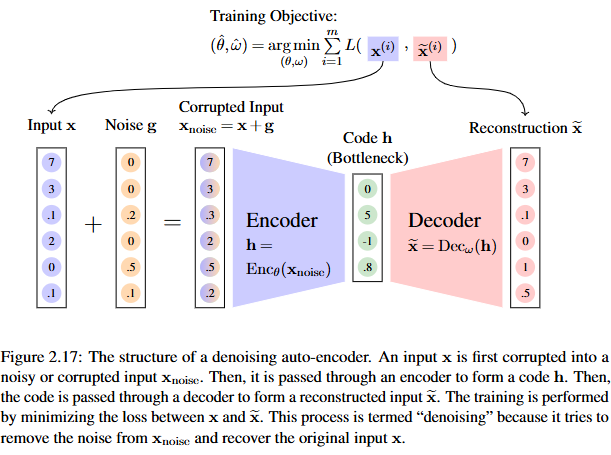

**Tạo corrupted input:**

$$x_{\text{noise}} \sim \Pr_{\text{noise}}(x_{\text{noise}} \mid x) \tag{2.106}$$

Các loại noise phổ biến:

| Loại noise | Mô tả | Ứng dụng |
|---|---|---|
| **Gaussian noise** | $x_{\text{noise}} = x + g$, $g \sim \mathcal{N}(0, \sigma^2 I)$ | Tổng quát |
| **Masking noise** | Set ngẫu nhiên một số entry về 0 | Language modeling (**BERT!**) |
| **Salt-and-pepper** | Set ngẫu nhiên entry về min/max | Image processing |

**Hàm mục tiêu** — tái tạo input **gốc** từ input **bị nhiễu**:

$$(\hat{\theta}, \hat{\omega}) = \arg\min_{(\theta,\omega)} \sum_{i=1}^m L\!\left(x^{(i)},\ \text{Dec}_\omega(\text{Enc}_\theta(x^{(i)}_{\text{noise}}))\right) \tag{2.110}$$

**So sánh CAE vs DAE:**

| | CAE | DAE |
|---|---|---|
| **Regularize tại** | Encoder (Jacobian) | Cả encoder + decoder |
| **Cơ chế** | Hạn chế độ nhạy của encoding | Học tái tạo từ input nhiễu |
| **Guidance** | Trực tiếp trên representation | Gián tiếp qua denoising signal |

---

## 2.6.3 Variational Auto-encoder (VAE)

### Mục Tiêu Khác Biệt

VAE **không phải** để học representation thuần túy — mục tiêu chính là **sinh ra dữ liệu mới** tương tự dữ liệu quan sát (generative model).

### Câu Chuyện Sinh (Generative Story)

Mỗi điểm dữ liệu $x$ được giả định sinh ra từ một **biến ẩn** $h$:

$$\Pr(x) = \int \Pr(x, h)\, dh = \int p_\omega(h) \cdot p_\omega(x \mid h)\, dh \tag{2.111-2.113}$$

**Prior:** $p_\omega(h)$ — thường là Gaussian chuẩn.

**Likelihood:** $p_\omega(x \mid h) = \mathcal{N}(\mu_p, \sigma_p^2 I)$, với $(\mu_p, \sigma_p) = \text{Dec}_\omega(h)$ — **decoder mạng nơ-ron**.

**Vấn đề:** Tích phân (2.112) không tính được → posterior $p_\omega(h \mid x)$ cũng intractable.

### Variational Inference — Xấp Xỉ Posterior

**VAE xấp xỉ** $p_\omega(h \mid x)$ bằng phân phối tractable $q_\theta(h \mid x)$:

$$q_\theta(h \mid x) = \mathcal{N}(\mu_q, \sigma_q^2 I), \quad (\mu_q, \sigma_q) = \text{Enc}_\theta(x) \tag{2.118-2.119}$$

**Encoder mạng nơ-ron** đầu ra **mean và variance** của phân phối $q$ — không phải một điểm cố định mà là một **phân phối**.

### Suy Dẫn ELBO

$$\log p_\omega(x) \geq \underbrace{\mathbb{E}_{h \sim q_\theta(h|x)}[\log p_\omega(x \mid h)]}_{\text{reconstruction term}} - \underbrace{D_{\text{KL}}(q_\theta(h \mid x) \| p_\omega(h))}_{\text{regularization term}} \tag{2.124}$$

Đây là **Evidence Lower Bound (ELBO)**. Maximize ELBO ↔ Minimize $-$ELBO.

**Ý nghĩa hai số hạng:**

| Số hạng | Ý nghĩa | Mục tiêu |
|---|---|---|
| **Reconstruction** | $\mathbb{E}[\log p_\omega(x \mid h)]$ | Decoder tái tạo $x$ tốt từ $h$ sampled |
| **KL regularization** | $D_{\text{KL}}(q_\theta \| p_\omega(h))$ | Posterior $q_\theta$ gần với prior Gaussian → $h$ có cấu trúc đẹp |

**Hàm mục tiêu:**

$$(\hat{\theta}, \hat{\omega}) = \arg\min_{(\theta,\omega)} \sum_{i=1}^m L(x^{(i)}, \theta, \omega) \tag{2.125}$$

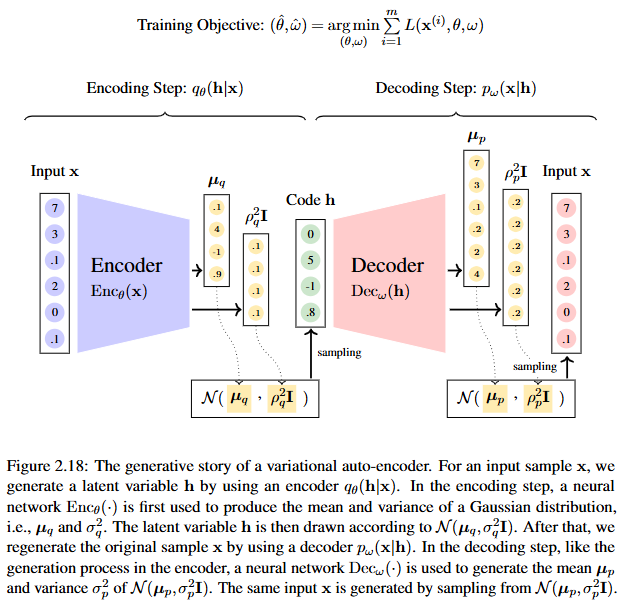

### Reparametrization Trick

**Vấn đề:** Sampling $h \sim q_\theta(h \mid x)$ là stochastic → không backprop được.

**Giải pháp:** Viết lại $h = \mu_q + \sigma_q \odot \varepsilon$, $\varepsilon \sim \mathcal{N}(0, I)$ → gradient chạy qua $\mu_q, \sigma_q$ (deterministic), không qua $\varepsilon$ (random).

### Inference vs Generation

**Training/Inference:** Encoder + Decoder cùng train để maximize ELBO.

**Generation (test time):** Bỏ encoder, **sample $h_{\text{new}} \sim \mathcal{N}(0, I)$** trực tiếp → Decoder sinh $x_{\text{new}}$ mới.

> **Sự khác biệt quan trọng:** Auto-encoder cổ điển học biểu diễn **điểm** (point estimate). VAE học biểu diễn **phân phối** — phản ánh uncertainty. Để dùng representation cho downstream task, lấy mean $\mu_q$ làm đại diện.

---

## Tổng Kết Mục 2.6

```
Mục tiêu học không giám sát:
  Học biểu diễn có ý nghĩa từ dữ liệu không nhãn
  → Tín hiệu training: reconstruction loss (tự tạo từ data)

Họ Auto-encoder:
┌─────────────────────────────────────────────────────┐
│ Undercomplete AE                                    │
│  x → Encoder → h (bottleneck) → Decoder → x̃       │
│  Mục tiêu: min L(x, x̃)                             │
├─────────────────────────────────────────────────────┤
│ Sparse AE                                           │
│  + L1/L2 penalty trên code h                        │
│  → Code thưa, đặc trưng độc lập                     │
├─────────────────────────────────────────────────────┤
│ Contractive AE                                      │
│  + Frobenius norm của Jacobian encoder              │
│  → Biểu diễn robust với input perturbation          │
├─────────────────────────────────────────────────────┤
│ Denoising AE                                        │
│  x + noise → Encoder → h → Decoder → x̃ ≈ x gốc   │
│  → Học từ corrupted input, robust reconstruction    │
├─────────────────────────────────────────────────────┤
│ Variational AE (VAE)                                │
│  Encoder → phân phối q(h|x)                        │
│  Decoder → phân phối p(x|h)                        │
│  Mục tiêu: maximize ELBO                            │
│  Ứng dụng: sinh dữ liệu mới                        │
└─────────────────────────────────────────────────────┘
```

| Loại | Regularize tại | Mục tiêu chính | Ứng dụng |
|---|---|---|---|
| Undercomplete | Bottleneck size | Nén thông tin | Feature extraction |
| Sparse | Code $h$ | Đặc trưng thưa | Sparse representation |
| Contractive | Jacobian encoder | Robust encoding | Stable representation |
| Denoising | Toàn bộ mạng | Robust reconstruction | Pre-training (BERT) |
| VAE | KL với prior | Latent space có cấu trúc | Generation, generative modeling |